# Reverse-engineer the `signaleringlijn` definition

**Goal:** `distance_to_signaleringlijn` tells us how far the current bank is from the signaleringlijn.  
We know three candidate lines for where the signaleringlijn might be defined (A, B, C).  
By subtracting `distance_to_signaleringlijn` from each candidate's distance-from-centreline, we get  
three *implied bank positions* per year. We then overlay those against the **actual measured bank points**  
to determine:

1. **Which candidate line matches the signaleringlijn** (the one whose implied bank best matches reality).
2. **What bank position the WOCU pipeline uses** (perpendicular distance vs area-based interpretation).

Candidate VVR reference lines (all relative to the centreline midpoint perpendicular):
- **A** – *first* crossing of the perpendicular ray with the VVR boundary (frontline)
- **B** – *last* (furthest) crossing of the perpendicular ray with the VVR boundary (backline)
- **C** – point on the VVR with maximum distance to the centreline

Focus region: `maas3_l_18640_18650` (previously established as a good discussion case).

In [11]:
import sys
sys.path.insert(0, '../../')

import subprocess
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely import offset_curve
from shapely.geometry import LineString, Point, MultiPoint
from shapely.ops import unary_union, transform as shp_transform
from pyproj import Transformer

from src import paths as PATHS

RAW_GPKG       = PATHS.DATA_DIR / '01_raw/erosion/wocu_output_fase2_20260210.gpkg'
PROCESSED_GPKG = PATHS.DATA_DIR / '02_processed/erosion/wocu_post_processed_fase2_20260223.gpkg'
VVR_GPKG       = PATHS.DATA_DIR / '01_raw/scope/Vlak_Vrijeruimte_ln.gpkg'

FOCUS_ID = 'maas3_l_18640_18650'
print('Data paths OK')

Data paths OK


## 1. Layer inventory (no fiona — uses ogrinfo)

In [12]:
def list_layers(gpkg_path):
    """Return list of layer names using ogrinfo (no fiona required)."""
    result = subprocess.run(
        ['ogrinfo', '-al', '-so', str(gpkg_path)],
        capture_output=True, text=True
    )
    layers = [line.split(': ', 1)[1].split(' ')[0]
              for line in result.stdout.splitlines()
              if line.startswith('Layer name:')]
    return layers

print('Processed gpkg layers:')
for l in list_layers(PROCESSED_GPKG):
    print(' -', l)

print()
print('Raw gpkg layers:')
for l in list_layers(RAW_GPKG):
    print(' -', l)

Processed gpkg layers:
 - all_lines
 - erosion_vlakken_filtered
 - summary_scope
 - vvr_rates_of_change
 - distances_percentiles
 - distance_differences
 - vvr_all_results

Raw gpkg layers:
 - vlakken_scope
 - centrelines
 - punten_oever
 - vlakken_erosie


## 2. Load data

In [13]:
# Bank measurement points + centrelines + scope
pts   = gpd.read_file(str(RAW_GPKG), layer='punten_oever')
cl    = gpd.read_file(str(RAW_GPKG), layer='centrelines')
scope = gpd.read_file(str(RAW_GPKG), layer='vlakken_scope')

# VVR boundary lines
vvr_ln = gpd.read_file(str(VVR_GPKG))

# WOCU time-series table (one row per position_id × annum)
vvr_ts = gpd.read_file(str(PROCESSED_GPKG), layer='vvr_all_results')

# Build lookups
cl_lookup    = cl.set_index('position_id')['geometry'].to_dict()
scope_lookup = scope.set_index('position_id')['geometry'].to_dict()

print(f'Bank points  : {len(pts):,}')
print(f'Centrelines  : {len(cl):,}')
print(f'Scope regions: {len(scope):,}')
print(f'VVR lines    : {len(vvr_ln):,}')
print(f'VVR TS rows  : {len(vvr_ts):,}')
print()
print('Bank point columns:', list(pts.columns))
print('VVR TS columns    :', list(vvr_ts.columns))

Bank points  : 4,844,655
Centrelines  : 12,130
Scope regions: 12,130
VVR lines    : 105
VVR TS rows  : 4,018

Bank point columns: ['z', 'dist', 'type_oever', 'status', 'location_id', 'dtm_version', 'dtm_date', 'geometry']
VVR TS columns    : ['eroded_area', 'total_vvr_area', 'percentage_consumed', 'distance_to_signaleringlijn', 'annum', 'position_id']


/Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/.venv/lib/python3.12/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'Vlak_Vrijeruimte_ln.gpkg': 'Vrijruimte_nevengeul_ln' (default), 'Vrijruimte_NVO_ln'. Specify layer parameter to avoid this warning.
  result = read_func(
/Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/.venv/lib/python3.12/site-packages/pyogrio/raw.py:200: RuntimeWarning: Non-conformant content for record 1 in column datummutatie, 2022-07-04T00:00:00+02:00, successfully parsed
  return ogr_read(


## 3. Helper geometry functions

In [14]:
def offset_toward_points(centreline, dist, bank_pts_geom):
    """Offset centreline by dist toward the side where bank points lie."""
    centroid = MultiPoint(list(bank_pts_geom)).centroid
    left  = offset_curve(centreline,  dist)
    right = offset_curve(centreline, -dist)
    if left  is None or left.is_empty:  return right
    if right is None or right.is_empty: return left
    mid_left  = left.interpolate(0.5,  normalized=True)
    mid_right = right.interpolate(0.5, normalized=True)
    return left if mid_left.distance(centroid) < mid_right.distance(centroid) else right


def _perpendicular_ray(cline, side, ray_len=5000):
    """Return a ray from the centreline midpoint perpendicular to *side* ('left' or 'right')."""
    mid_param = cline.length / 2
    mid_pt    = cline.interpolate(mid_param)
    eps       = min(1.0, cline.length * 0.01)
    p_before  = cline.interpolate(max(0.0, mid_param - eps))
    p_after   = cline.interpolate(min(cline.length, mid_param + eps))
    dx = p_after.x - p_before.x
    dy = p_after.y - p_before.y
    dn = np.hypot(dx, dy)
    # left-perp: (-dy, dx);  right-perp: (dy, -dx)
    px, py = (-dy / dn, dx / dn) if side == 'left' else (dy / dn, -dx / dn)
    return LineString([
        (mid_pt.x, mid_pt.y),
        (mid_pt.x + px * ray_len, mid_pt.y + py * ray_len)
    ])


def _sorted_crossings(ray, vvr_union):
    """Intersect ray with vvr_union; return list of Points sorted by distance from ray origin."""
    inter = ray.intersection(vvr_union)
    if inter.is_empty:
        return []
    origin = Point(ray.coords[0])
    if inter.geom_type == 'Point':
        pts_ = [inter]
    elif inter.geom_type == 'MultiPoint':
        pts_ = list(inter.geoms)
    elif inter.geom_type == 'GeometryCollection':
        pts_ = [g for g in inter.geoms if g.geom_type == 'Point']
    else:
        pts_ = []
    return sorted(pts_, key=lambda p: origin.distance(p))


def compute_three_candidates(cline, vvr_union, bank_pts_geom):
    """
    Compute the three candidate VVR reference lines.

    Returns a dict with keys 'A', 'B', 'C', each containing:
      'dist'  – distance from centreline (metres)
      'point' – the reference Point on the VVR
      'line'  – the offset LineString (parallel to centreline)
    or None if the candidate cannot be computed.
    """
    if cline is None or vvr_union is None or vvr_union.is_empty:
        return {'A': None, 'B': None, 'C': None}

    # Determine which side the bank is on, then shoot ray that direction
    centroid = MultiPoint(list(bank_pts_geom)).centroid
    ray_left  = _perpendicular_ray(cline, 'left')
    ray_right = _perpendicular_ray(cline, 'right')
    mid_pt    = cline.interpolate(cline.length / 2)
    side      = 'left' if mid_pt.distance(centroid) < ray_left.distance(centroid) else 'right'
    # Actually determine which side the centroid is on using signed area
    cross_l = _sorted_crossings(ray_left, vvr_union)
    cross_r = _sorted_crossings(ray_right, vvr_union)
    # Use whichever ray has more crossings (or the one centroid is closer to)
    crossings = cross_l if len(cross_l) >= len(cross_r) else cross_r
    ray       = ray_left if crossings is cross_l else ray_right

    origin = Point(cline.interpolate(cline.length / 2))

    results = {}

    # ── Option A: first (nearest) crossing ──────────────────────────────────
    if crossings:
        pt_A   = crossings[0]
        dist_A = origin.distance(pt_A)
        line_A = offset_toward_points(cline, dist_A, bank_pts_geom)
        results['A'] = {'dist': dist_A, 'point': pt_A, 'line': line_A}
    else:
        results['A'] = None

    # ── Option B: last (furthest) crossing ──────────────────────────────────
    if crossings:
        pt_B   = crossings[-1]
        dist_B = origin.distance(pt_B)
        line_B = offset_toward_points(cline, dist_B, bank_pts_geom)
        results['B'] = {'dist': dist_B, 'point': pt_B, 'line': line_B}
    else:
        results['B'] = None

    # ── Option C: point of maximum distance on VVR to centreline ────────────
    try:
        geoms = list(vvr_union.geoms) if vvr_union.geom_type.startswith('Multi') else [vvr_union]
        all_coords = []
        for g in geoms:
            if hasattr(g, 'geoms'):
                for sub in g.geoms:
                    all_coords.extend(sub.coords)
            else:
                all_coords.extend(g.coords)
        pts_on_vvr = [Point(c) for c in all_coords]
        dists      = [cline.distance(p) for p in pts_on_vvr]
        idx_max    = int(np.argmax(dists))
        pt_C       = pts_on_vvr[idx_max]
        dist_C     = dists[idx_max]
        line_C     = offset_toward_points(cline, dist_C, bank_pts_geom)
        results['C'] = {'dist': dist_C, 'point': pt_C, 'line': line_C}
    except Exception:
        results['C'] = None

    return results


print('Helper functions defined.')

Helper functions defined.


## 4. Set up focus region

In [15]:
# ── geometry for focus region ─────────────────────────────────────────────────
cline      = cl_lookup.get(FOCUS_ID)
scope_geom = scope_lookup.get(FOCUS_ID)

# Bank points for this region
local_pts = pts[pts['location_id'] == FOCUS_ID].copy()
years_pts = sorted(local_pts['dtm_date'].unique())

# VVR lines that intersect scope (200 m buffer)
local_vvr = vvr_ln[vvr_ln.intersects(scope_geom.buffer(200))] if scope_geom else gpd.GeoDataFrame()
vvr_union = unary_union(local_vvr.geometry) if not local_vvr.empty else None

# WOCU time-series for this region
local_ts  = vvr_ts[vvr_ts['position_id'] == FOCUS_ID].sort_values('annum').copy()

print(f'Focus region : {FOCUS_ID}')
print(f'CL geom      : {cline.geom_type if cline else "NOT FOUND"}')
print(f'Scope geom   : {scope_geom.geom_type if scope_geom else "NOT FOUND"}')
print(f'Bank point years (dtm_date): {years_pts}')
print(f'VVR lines found : {len(local_vvr)}')
print()
print('WOCU time-series:')
print(local_ts[['annum', 'distance_to_signaleringlijn', 'percentage_consumed', 'eroded_area']]
      .to_string(index=False))

Focus region : maas3_l_18640_18650
CL geom      : LineString
Scope geom   : Polygon
Bank point years (dtm_date): [np.int64(2016), np.int64(2021), np.int64(2024)]
VVR lines found : 1

WOCU time-series:
 annum  distance_to_signaleringlijn  percentage_consumed  eroded_area
  2016                   -60.122495            46.788642   882.644004
  2021                   -25.752089            44.204584   833.897073
  2024                   -94.556861            38.128481   719.274465


## 5. Compute three VVR candidate lines

In [16]:
bank_pts_geom = list(local_pts.geometry)
candidates    = compute_three_candidates(cline, vvr_union, bank_pts_geom)

for key, val in candidates.items():
    if val:
        print(f'Option {key}: dist from CL = {val["dist"]:.2f} m')
    else:
        print(f'Option {key}: NOT AVAILABLE')

Option A: dist from CL = 134.22 m
Option B: dist from CL = 175.77 m
Option C: dist from CL = 203.53 m


## 6. Core analysis — one plot per measured year

For each WOCU measurement year, and for each candidate VVR reference (A, B, C):

```
implied_bank_dist = candidate_dist - distance_to_signaleringlijn
```

We draw the implied bank line alongside the actual measured bank points.  
The candidate whose implied bank line best matches the actual points identifies  
the real signaleringlijn definition used by the WOCU pipeline.

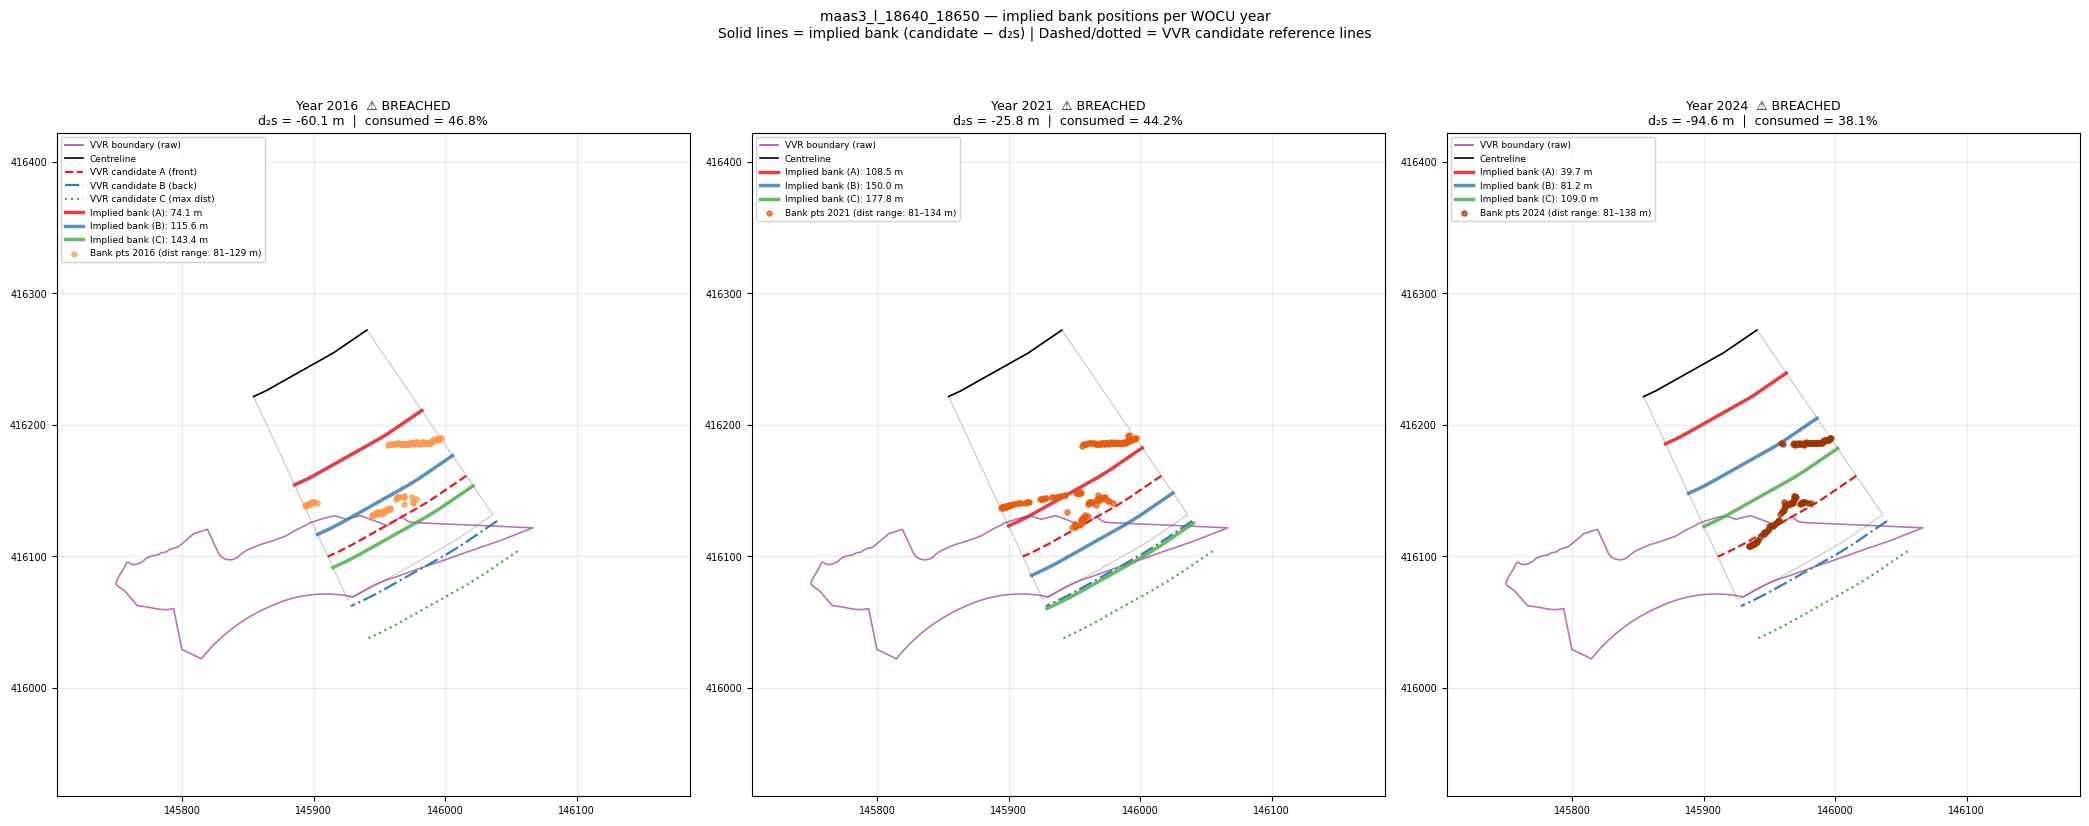

In [17]:
# ── colour palette ────────────────────────────────────────────────────────────
CAND_STYLE = {
    'A': {'color': '#e41a1c', 'ls': '--',  'lw': 1.6, 'label': 'VVR candidate A (front)'},
    'B': {'color': '#377eb8', 'ls': '-.',  'lw': 1.6, 'label': 'VVR candidate B (back)'},
    'C': {'color': '#4daf4a', 'ls': ':',   'lw': 1.6, 'label': 'VVR candidate C (max dist)'},
}
IMP_STYLE = {
    'A': {'color': '#e41a1c', 'ls': '-',  'lw': 2.5, 'alpha': 0.85},
    'B': {'color': '#377eb8', 'ls': '-',  'lw': 2.5, 'alpha': 0.85},
    'C': {'color': '#4daf4a', 'ls': '-',  'lw': 2.5, 'alpha': 0.85},
}
PT_COLORS   = plt.cm.Oranges(np.linspace(0.45, 0.9, max(len(years_pts), 1)))


def flatten_geom_coords(geom):
    """Yield (x_array, y_array) pairs for any geometry type."""
    if geom is None or geom.is_empty:
        return
    if geom.geom_type in ('LineString', 'LinearRing'):
        xs, ys = zip(*geom.coords)
        yield list(xs), list(ys)
    elif geom.geom_type == 'MultiLineString':
        for sub in geom.geoms:
            yield from flatten_geom_coords(sub)
    elif geom.geom_type == 'Polygon':
        xs, ys = zip(*geom.exterior.coords)
        yield list(xs), list(ys)
    elif geom.geom_type in ('MultiPolygon', 'GeometryCollection'):
        for sub in geom.geoms:
            yield from flatten_geom_coords(sub)


# ── one figure per WOCU measurement year ────────────────────────────────────
n_rows = len(local_ts)
if n_rows == 0:
    print('No WOCU time-series rows for this region.')
else:
    fig, axes = plt.subplots(1, n_rows, figsize=(7 * n_rows, 9), squeeze=False)
    axes = axes[0]  # single row of subplots

    # Compute global axis bounds from scope + a small buffer
    if scope_geom:
        minx, miny, maxx, maxy = scope_geom.buffer(150).bounds
    else:
        all_x = [p.x for p in bank_pts_geom]
        all_y = [p.y for p in bank_pts_geom]
        pad   = 200
        minx, miny = min(all_x) - pad, min(all_y) - pad
        maxx, maxy = max(all_x) + pad, max(all_y) + pad

    for col_idx, (_, ts_row) in enumerate(local_ts.iterrows()):
        ax   = axes[col_idx]
        year = int(ts_row['annum'])
        d2s  = ts_row['distance_to_signaleringlijn']
        pct  = ts_row['percentage_consumed']

        # ── background: scope boundary ───────────────────────────────────────
        if scope_geom:
            for xs, ys in flatten_geom_coords(scope_geom):
                ax.plot(xs, ys, color='grey', lw=0.7, linestyle='-', alpha=0.5, zorder=1)

        # ── VVR boundary (raw signaleringlijn geometry) ───────────────────────
        for _, vrow in local_vvr.iterrows():
            for xs, ys in flatten_geom_coords(vrow.geometry):
                ax.plot(xs, ys, color='purple', lw=1.2, alpha=0.55, zorder=2,
                        label='_nolegend_')
        # One legend entry for VVR
        ax.plot([], [], color='purple', lw=1.2, alpha=0.7, label='VVR boundary (raw)')

        # ── centreline ───────────────────────────────────────────────────────
        if cline:
            cx, cy = zip(*cline.coords)
            ax.plot(cx, cy, color='black', lw=1.2, zorder=3, label='Centreline')

        # ── three VVR candidate lines ─────────────────────────────────────────
        for key, cand in candidates.items():
            if cand is None:
                continue
            st = CAND_STYLE[key]
            for xs, ys in flatten_geom_coords(cand['line']):
                ax.plot(xs, ys, color=st['color'], ls=st['ls'], lw=st['lw'],
                        zorder=4, label=st['label'])
                st['label'] = '_nolegend_'  # only first segment gets legend entry

        # ── implied bank lines (candidate_dist - distance_to_signaleringlijn) ─
        for key, cand in candidates.items():
            if cand is None:
                continue
            implied_dist = cand['dist'] + d2s
            implied_line = offset_toward_points(cline, implied_dist, bank_pts_geom)
            st = IMP_STYLE[key]
            if implied_line and not implied_line.is_empty:
                for xs, ys in flatten_geom_coords(implied_line):
                    ax.plot(xs, ys, color=st['color'], ls=st['ls'], lw=st['lw'],
                            alpha=st['alpha'], zorder=6,
                            label=f'Implied bank ({key}): {implied_dist:.1f} m')

        # ── actual measured bank points for this year ─────────────────────────
        # Find the dtm_date closest to the WOCU annum
        yr_pts_candidates = [
            d for d in years_pts
            if abs(int(str(d)[:4]) - year) <= 1   # within 1 year
        ]
        if not yr_pts_candidates:
            yr_pts_candidates = years_pts  # fall back to all years

        for di, dtm in enumerate(yr_pts_candidates):
            yr_sub = local_pts[local_pts['dtm_date'] == dtm]
            ax.scatter(
                yr_sub.geometry.x, yr_sub.geometry.y,
                s=14, alpha=0.7, zorder=8,
                color=PT_COLORS[years_pts.index(dtm)],
                label=f'Bank pts {dtm} (dist range: {yr_sub["dist"].min():.0f}–{yr_sub["dist"].max():.0f} m)'
            )

        # ── annotations ──────────────────────────────────────────────────────
        breached = '⚠ BREACHED' if d2s < 0 else ''
        ax.set_title(
            f'Year {year}  {breached}\n'
            f'd₂s = {d2s:.1f} m  |  consumed = {pct:.1f}%',
            fontsize=9
        )
        ax.set_xlim(minx, maxx)
        ax.set_ylim(miny, maxy)
        ax.set_aspect('equal')
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=6.5, loc='upper left', framealpha=0.85)
        ax.grid(True, alpha=0.25)

    fig.suptitle(
        f'{FOCUS_ID} — implied bank positions per WOCU year\n'
        'Solid lines = implied bank (candidate − d₂s) | '
        'Dashed/dotted = VVR candidate reference lines',
        fontsize=10
    )
    plt.tight_layout()
    plt.show()

## 7. Numerical summary table

For each year: the three candidate distances, the implied bank distances, and the actual measured bank distance range.

In [18]:
rows = []
for _, ts_row in local_ts.iterrows():
    year = int(ts_row['annum'])
    d2s  = ts_row['distance_to_signaleringlijn']

    # Closest measured year
    closest_dtm = min(years_pts, key=lambda d: abs(int(str(d)[:4]) - year)) if years_pts else None
    yr_pts_sub  = local_pts[local_pts['dtm_date'] == closest_dtm] if closest_dtm else pd.DataFrame()

    row = {
        'WOCU year'       : year,
        'd₂s (m)'         : round(d2s, 2),
        '% consumed'      : round(ts_row['percentage_consumed'], 2),
        'closest dtm_date': closest_dtm,
        'actual bank min (m)': round(yr_pts_sub['dist'].min(), 1) if not yr_pts_sub.empty else np.nan,
        'actual bank max (m)': round(yr_pts_sub['dist'].max(), 1) if not yr_pts_sub.empty else np.nan,
    }
    for key, cand in candidates.items():
        if cand:
            row[f'cand {key} dist (m)']    = round(cand['dist'], 2)
            row[f'implied bank {key} (m)'] = round(cand['dist'] + d2s, 2)
        else:
            row[f'cand {key} dist (m)']    = np.nan
            row[f'implied bank {key} (m)'] = np.nan
    rows.append(row)

summary = pd.DataFrame(rows)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)
print(summary.to_string(index=False))
print()
print('Interpretation:')
print('  The implied bank line closest to [actual bank min–max] identifies')
print('  the candidate that best represents the signaleringlijn.')

 WOCU year  d₂s (m)  % consumed  closest dtm_date  actual bank min (m)  actual bank max (m)  cand A dist (m)  implied bank A (m)  cand B dist (m)  implied bank B (m)  cand C dist (m)  implied bank C (m)
      2016   -60.12       46.79              2016                 81.2                129.3           134.22               74.09           175.77              115.65           203.53              143.41
      2021   -25.75       44.20              2021                 80.9                133.5           134.22              108.47           175.77              150.02           203.53              177.78
      2024   -94.56       38.13              2024                 81.4                138.0           134.22               39.66           175.77               81.21           203.53              108.97

Interpretation:
  The implied bank line closest to [actual bank min–max] identifies
  the candidate that best represents the signaleringlijn.


## 8. Same analysis for other regions with shared data

Run the same per-year plot for a few more regions to cross-validate which candidate consistently matches.

In [19]:
# Find regions that have both bank points AND WOCU ts, with ≥ 2 WOCU years
vvr_ids  = set(vvr_ts['position_id'].unique())
pts_ids  = set(pts['location_id'].unique())
shared   = vvr_ids & pts_ids

ts_counts = vvr_ts[vvr_ts['position_id'].isin(shared)].groupby('position_id')['annum'].count()
good_ids  = ts_counts[ts_counts >= 2].index.tolist()

# Pick 3 additional regions (different rivers if possible), skip focus region
EXTRA_IDS = []
for river in ['rijn', 'ijssel', 'neder', 'maas']:
    matches = [x for x in good_ids if river in x and x != FOCUS_ID]
    if matches:
        EXTRA_IDS.append(matches[0])
    if len(EXTRA_IDS) == 3:
        break

print('Additional regions for cross-validation:')
for rid in EXTRA_IDS:
    sub = vvr_ts[vvr_ts['position_id'] == rid]
    print(f'  {rid}: years = {sorted(sub["annum"].tolist())}, '
          f'd2s range = {sub["distance_to_signaleringlijn"].min():.1f} .. '
          f'{sub["distance_to_signaleringlijn"].max():.1f} m')

Additional regions for cross-validation:
  nederrijn_l_1490_1500: years = [2015, 2020, 2024], d2s range = -65.9 .. -60.3 m
  ijssel1_l_10290_10300: years = [2017, 2022, 2025], d2s range = -112.0 .. -110.7 m
  nederrijn_l_1490_1500: years = [2015, 2020, 2024], d2s range = -65.9 .. -60.3 m



────────────────────────────────────────────────────────────
 nederrijn_l_1490_1500
────────────────────────────────────────────────────────────


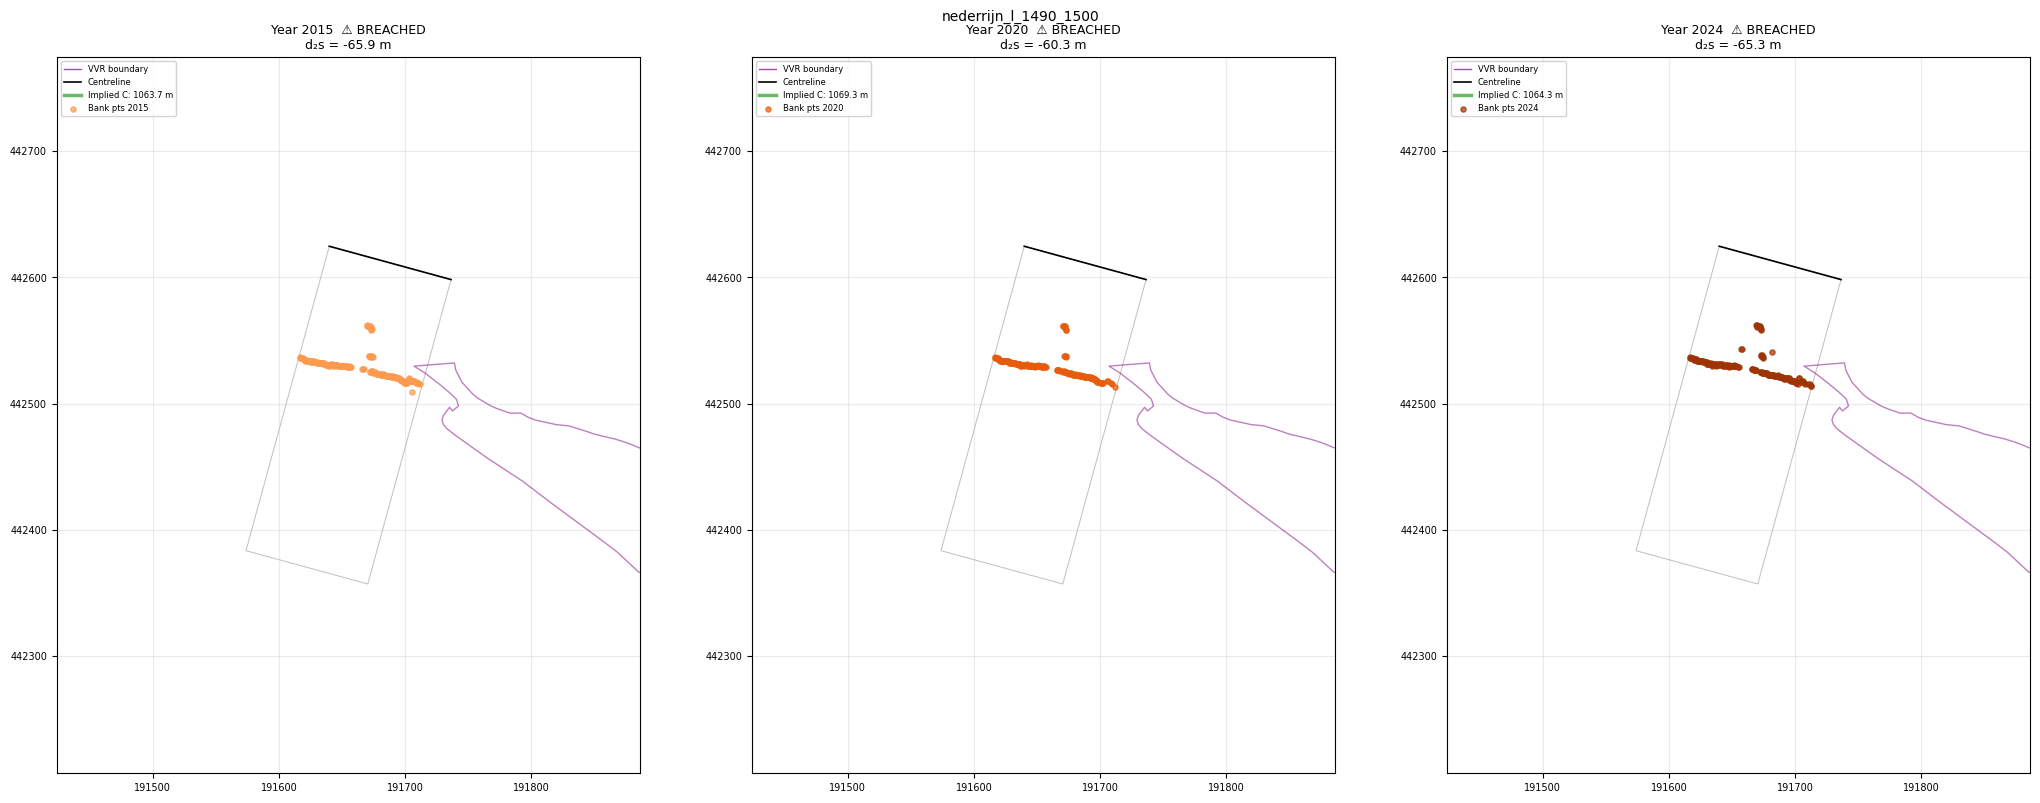


────────────────────────────────────────────────────────────
 ijssel1_l_10290_10300
────────────────────────────────────────────────────────────


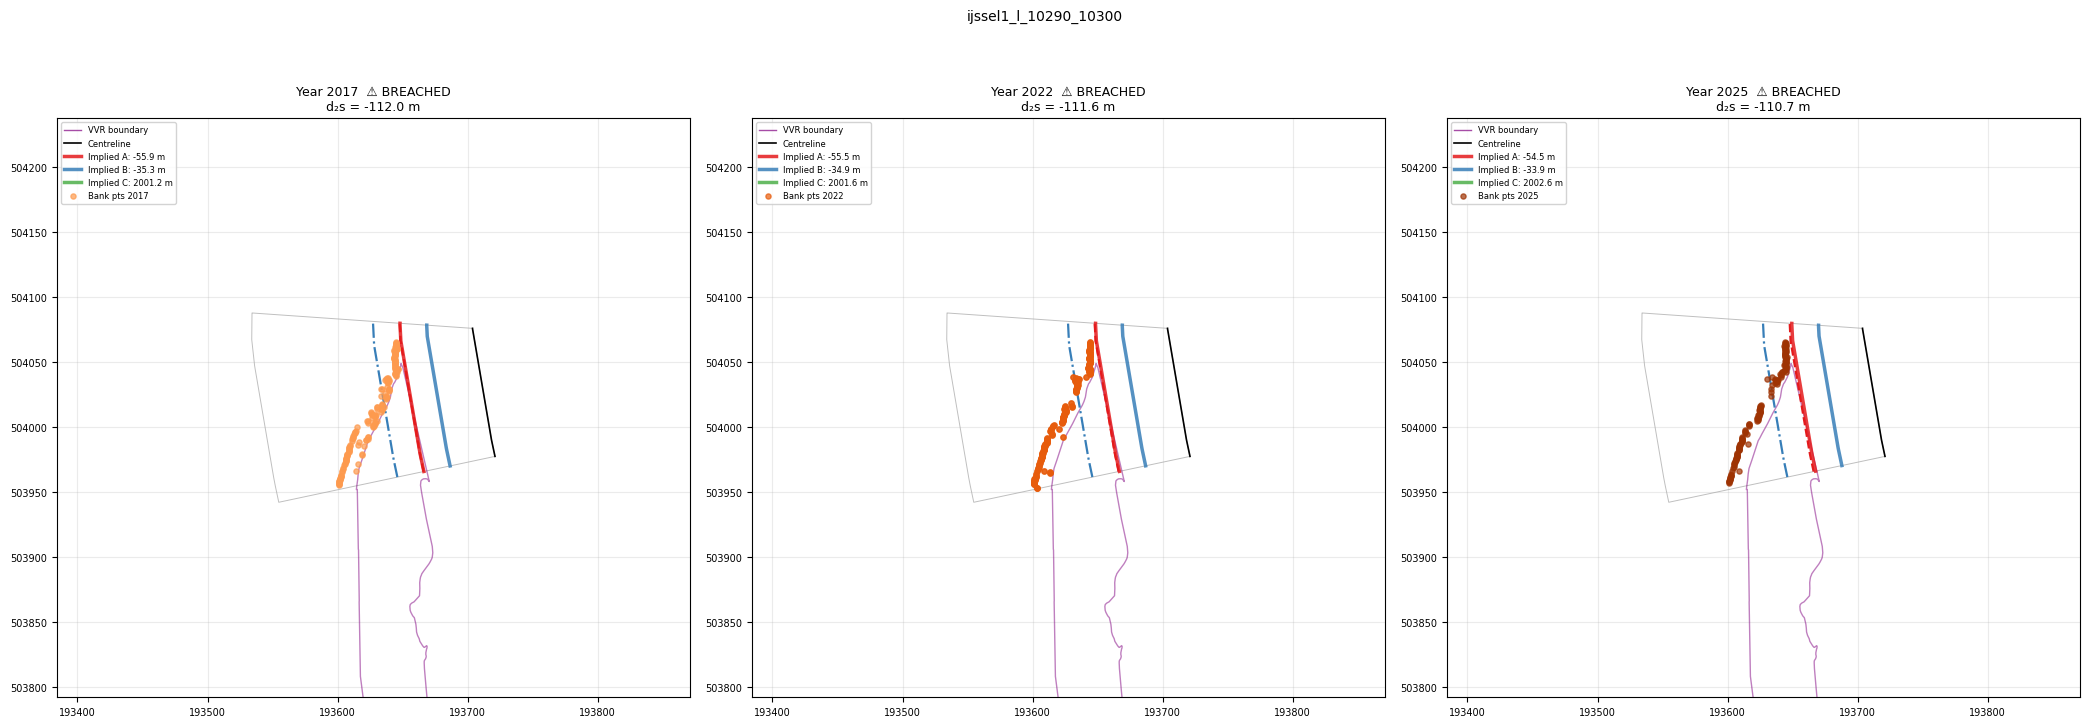


────────────────────────────────────────────────────────────
 nederrijn_l_1490_1500
────────────────────────────────────────────────────────────


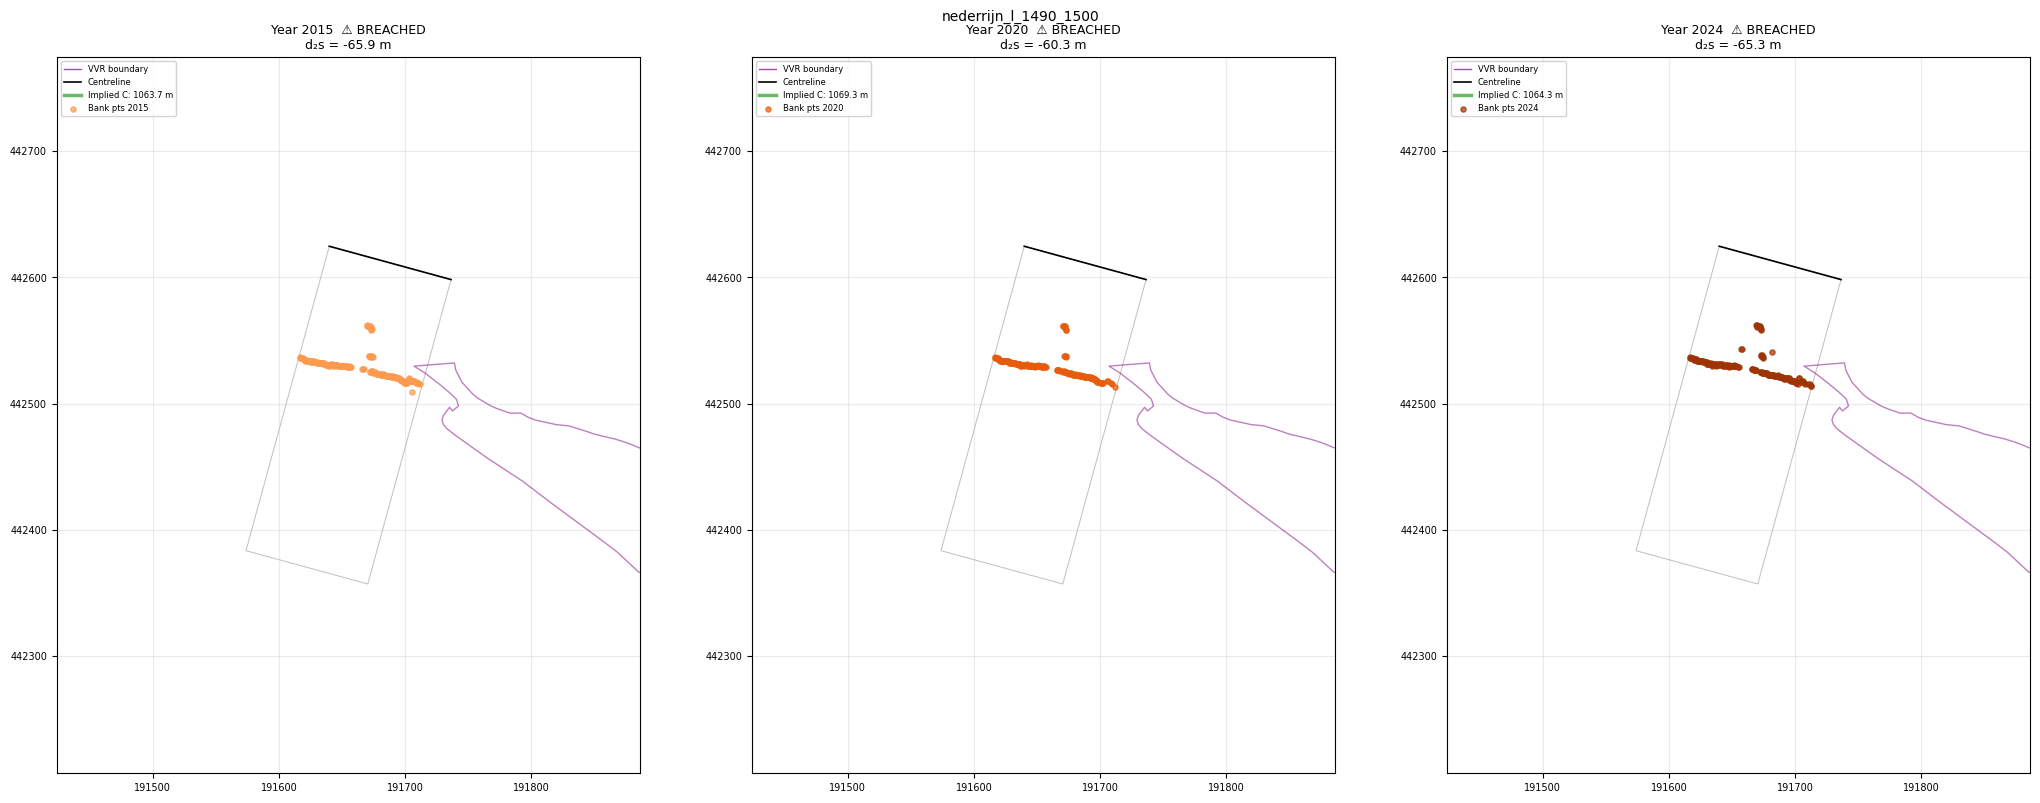

In [20]:
def plot_region_per_year(region_id):
    cline_r      = cl_lookup.get(region_id)
    scope_r      = scope_lookup.get(region_id)
    local_pts_r  = pts[pts['location_id'] == region_id].copy()
    years_pts_r  = sorted(local_pts_r['dtm_date'].unique())
    local_vvr_r  = vvr_ln[vvr_ln.intersects(scope_r.buffer(200))] if scope_r else gpd.GeoDataFrame()
    vvr_union_r  = unary_union(local_vvr_r.geometry) if not local_vvr_r.empty else None
    local_ts_r   = vvr_ts[vvr_ts['position_id'] == region_id].sort_values('annum')

    if cline_r is None or vvr_union_r is None or local_ts_r.empty:
        print(f'  Skipping {region_id} — missing geometry or TS data.')
        return

    bank_pts_r = list(local_pts_r.geometry)
    cands_r    = compute_three_candidates(cline_r, vvr_union_r, bank_pts_r)

    n_cols = len(local_ts_r)
    if n_cols == 0:
        return

    fig, axes = plt.subplots(1, n_cols, figsize=(7 * n_cols, 8), squeeze=False)
    axes = axes[0]

    if scope_r:
        minx, miny, maxx, maxy = scope_r.buffer(150).bounds
    else:
        all_x = [p.x for p in bank_pts_r]
        all_y = [p.y for p in bank_pts_r]
        pad   = 200
        minx, miny = min(all_x) - pad, min(all_y) - pad
        maxx, maxy = max(all_x) + pad, max(all_y) + pad

    pt_colors_r = plt.cm.Oranges(np.linspace(0.45, 0.9, max(len(years_pts_r), 1)))

    for col_idx, (_, ts_row) in enumerate(local_ts_r.iterrows()):
        ax   = axes[col_idx]
        year = int(ts_row['annum'])
        d2s  = ts_row['distance_to_signaleringlijn']

        if scope_r:
            for xs, ys in flatten_geom_coords(scope_r):
                ax.plot(xs, ys, color='grey', lw=0.7, alpha=0.5, zorder=1)

        for _, vrow in local_vvr_r.iterrows():
            for xs, ys in flatten_geom_coords(vrow.geometry):
                ax.plot(xs, ys, color='purple', lw=1.0, alpha=0.5, zorder=2)
        ax.plot([], [], color='purple', lw=1.0, alpha=0.7, label='VVR boundary')

        if cline_r:
            cx, cy = zip(*cline_r.coords)
            ax.plot(cx, cy, color='black', lw=1.2, zorder=3, label='Centreline')

        first_label = {k: True for k in 'ABC'}
        for key, cand in cands_r.items():
            if cand is None:
                continue
            st = CAND_STYLE[key]
            lbl = st['label'] if first_label[key] else '_nolegend_'
            for xs, ys in flatten_geom_coords(cand['line']):
                ax.plot(xs, ys, color=st['color'], ls=st['ls'], lw=st['lw'], zorder=4, label=lbl)
                first_label[key] = False

        for key, cand in cands_r.items():
            if cand is None:
                continue
            implied_dist = cand['dist'] + d2s
            implied_line = offset_toward_points(cline_r, implied_dist, bank_pts_r)
            st = IMP_STYLE[key]
            if implied_line and not implied_line.is_empty:
                for xs, ys in flatten_geom_coords(implied_line):
                    ax.plot(xs, ys, color=st['color'], ls='-', lw=st['lw'],
                            alpha=st['alpha'], zorder=6,
                            label=f'Implied {key}: {implied_dist:.1f} m')

        yr_dtm = min(years_pts_r, key=lambda d: abs(int(str(d)[:4]) - year)) if years_pts_r else None
        if yr_dtm:
            yr_sub = local_pts_r[local_pts_r['dtm_date'] == yr_dtm]
            ax.scatter(yr_sub.geometry.x, yr_sub.geometry.y, s=14, alpha=0.7, zorder=8,
                       color=pt_colors_r[years_pts_r.index(yr_dtm)],
                       label=f'Bank pts {yr_dtm}')

        breached = '⚠ BREACHED' if d2s < 0 else ''
        ax.set_title(f'Year {year}  {breached}\nd₂s = {d2s:.1f} m', fontsize=9)
        ax.set_xlim(minx, maxx)
        ax.set_ylim(miny, maxy)
        ax.set_aspect('equal')
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=6, loc='upper left', framealpha=0.85)
        ax.grid(True, alpha=0.25)

    fig.suptitle(f'{region_id}', fontsize=10)
    plt.tight_layout()
    plt.show()


for rid in EXTRA_IDS:
    print(f'\n{"─"*60}')
    print(f' {rid}')
    print(f'{"─"*60}')
    plot_region_per_year(rid)